# Villalva single-diode model: parameter extraction and I–V curves

This notebook is organized as a compact pvlib-style example, analogous to the
De Soto workflow:

1. extract the five single-diode equation (SDM) parameters at STC from
   manufacturer datasheet values using Villalva's iterative fitting method;
2. inspect the evolution of the modeled maximum power as the series resistance
   \(R_s\) is incremented;
3. validate the fitted STC I–V curve against the datasheet key points;
4. calculate the SDM parameters at different operating conditions using
   Villalva's temperature and irradiance equations;
5. solve and plot the resulting operating-condition I–V curves with pvlib.

The implementation is based on Villalva's thesis, Chapter 3 and Appendix A,
and Villalva, Gazoli, and Ruppert Filho (2009).

The example PV module is the **JA Solar JAM78D40-625/MB**.

References
----------
- M. G. Villalva, PhD thesis, Chapter 3 and Appendix A.
- M. G. Villalva, J. R. Gazoli, E. Ruppert Filho,
  "Comprehensive Approach to Modeling and Simulation of Photovoltaic Arrays",
  IEEE Transactions on Power Electronics, 2009.
- pvlib De Soto example:
  https://pvlib-python.readthedocs.io/en/stable/gallery/iv-modeling/plot_singlediode.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import constants

from pvlib import pvsystem

## Proposed `pvlib.ivtools.sdm.fit_villalva`

Villalva's basic fitting method assumes that the diode ideality factor \(a\)
is supplied by the user.

The algorithm increments \(R_s\) from zero. For each candidate \(R_s\), the
corresponding \(R_{sh}\), \(I_L\), and \(I_0\) are calculated and the maximum
power of the resulting single-diode model is evaluated. The selected solution
is the one that minimizes

\[
P_mp,experimental - V_mp * I_mp.
\]

The helper function below combines Villalva's MPP relation, photocurrent
correction, and finite-\(R_{sh}\) open-circuit equation for one candidate
\(R_s\). This keeps each stored iteration internally self-consistent while
preserving Villalva's explicit outer \(R_s\) search.

In [2]:
def _villalva_params_at_rs(
    resistance_series,
    v_mp,
    i_mp,
    v_oc,
    i_sc,
    a_ref,
):
    """Calculate I_L, I_o and R_sh for one candidate R_s."""

    exp_voc = np.expm1(v_oc / a_ref)
    exp_vmp = np.expm1(
        (v_mp + i_mp * resistance_series) / a_ref
    )

    p_mp = v_mp * i_mp

    # Algebraic combination of Villalva's equations:
    #
    # I_L = (R_sh + R_s) / R_sh * I_sc
    #
    # I_o = (I_L - V_oc / R_sh) /
    #       (exp(V_oc / a_ref) - 1)
    #
    # and the R_sh(R_s) relation obtained at the MPP.
    A = (
        v_mp * i_sc
        - v_mp * i_sc * exp_vmp / exp_voc
        - p_mp
    )

    B = (
        v_mp * i_sc * resistance_series
        - v_mp
        * (i_sc * resistance_series - v_oc)
        * exp_vmp / exp_voc
    )

    resistance_shunt = (
        v_mp * (v_mp + i_mp * resistance_series) - B
    ) / A

    photocurrent = (
        (resistance_shunt + resistance_series)
        / resistance_shunt
        * i_sc
    )

    saturation_current = (
        photocurrent - v_oc / resistance_shunt
    ) / exp_voc

    return photocurrent, saturation_current, resistance_shunt

In [3]:
def fit_villalva(
    v_mp,
    i_mp,
    v_oc,
    i_sc,
    alpha_sc,
    beta_voc,
    cells_in_series,
    diode_factor,
    temp_ref=25.0,
    irrad_ref=1000.0,
    rs_step=1e-4,
    rs_max=None,
):
    """Fit Villalva single-diode model parameters from datasheet values.

    The series resistance is swept from 0 to ``rs_max``.
    The selected solution is the valid iteration that gives the
    minimum absolute difference between modeled and reference Pmp.

    Parameters
    ----------
    v_mp : float
        Maximum-power voltage at reference conditions [V].
    i_mp : float
        Maximum-power current at reference conditions [A].
    v_oc : float
        Open-circuit voltage at reference conditions [V].
    i_sc : float
        Short-circuit current at reference conditions [A].
    alpha_sc : float
        Short-circuit current temperature coefficient [A/K].
    beta_voc : float
        Open-circuit voltage temperature coefficient [V/K].
    cells_in_series : int
        Effective number of cells/junctions connected in series.
    diode_factor : float
        Dimensionless diode ideality factor used by Villalva.
    temp_ref : float, default 25
        Reference cell temperature [degC].
    irrad_ref : float, default 1000
        Reference irradiance [W/m2].
    rs_step : float, default 1e-4
        Increment of series resistance [ohm].
    rs_max : float, optional
        Maximum series resistance considered [ohm].
        If None, ``v_oc / i_sc`` is used.

    Returns
    -------
    params : dict
        Fitted Villalva reference parameters.
    history : pandas.DataFrame
        Full fitting history as R_s is incremented.
    """

    temp_ref_k = temp_ref + 273.15

    # a_ref = a * Ns * kT/q
    a_ref = (
        diode_factor
        * cells_in_series
        * constants.k
        * temp_ref_k
        / constants.e
    )

    p_mp_ref = v_mp * i_mp

    # Villalva minimum shunt resistance.
    r_sh_min = (
        v_mp / (i_sc - i_mp)
        - (v_oc - v_mp) / i_mp
    )

    if r_sh_min <= 0:
        raise ValueError("Villalva R_sh_min must be positive.")

    if rs_max is None:
        rs_max = v_oc / i_sc

    rows = []

    rs_values = np.arange(
        0.0,
        rs_max + 0.5 * rs_step,
        rs_step,
    )

    for resistance_series in rs_values:

        try:
            photocurrent, saturation_current, resistance_shunt = (
                _villalva_params_at_rs(
                    resistance_series,
                    v_mp,
                    i_mp,
                    v_oc,
                    i_sc,
                    a_ref,
                )
            )
        except (FloatingPointError, ZeroDivisionError):
            continue

        if (
            not np.isfinite(resistance_shunt)
            or resistance_shunt < r_sh_min
            or photocurrent <= 0
            or saturation_current <= 0
        ):
            continue

        try:
            mpp = pvsystem.max_power_point(
                photocurrent=photocurrent,
                saturation_current=saturation_current,
                resistance_series=resistance_series,
                resistance_shunt=resistance_shunt,
                nNsVth=a_ref,
                method="brentq",
            )
        except (ValueError, RuntimeError):
            continue

        p_mp_model = float(np.asarray(mpp["p_mp"]))
        power_error = p_mp_model - p_mp_ref

        rows.append({
            "R_s": resistance_series,
            "R_sh_ref": resistance_shunt,
            "I_L_ref": photocurrent,
            "I_o_ref": saturation_current,
            "v_mp_model": float(np.asarray(mpp["v_mp"])),
            "i_mp_model": float(np.asarray(mpp["i_mp"])),
            "p_mp_model": p_mp_model,
            "p_mp_ref": p_mp_ref,
            "power_error": power_error,
            "abs_power_error": abs(power_error),
        })

    if not rows:
        raise RuntimeError("No valid Villalva solution was found.")

    history = pd.DataFrame(rows)

    # Select the Rs that gives the closest modeled Pmp to Vmp * Imp.
    best = history.loc[
        history["abs_power_error"].idxmin()
    ]

    params = {
        "I_L_ref": float(best["I_L_ref"]),
        "I_o_ref": float(best["I_o_ref"]),
        "R_s": float(best["R_s"]),
        "R_sh_ref": float(best["R_sh_ref"]),
        "a_ref": float(a_ref),
        "alpha_sc": alpha_sc,
        "beta_voc": beta_voc,
        "i_sc_ref": i_sc,
        "v_oc_ref": v_oc,
        "irrad_ref": irrad_ref,
        "temp_ref": temp_ref,
    }

    return params, history

## Proposed `pvlib.pvsystem.calcparams_villalva`

Villalva models the photocurrent as

\[
I_L =
\left(I_{L,\mathrm{ref}}+\alpha_{sc}\Delta T\right)
\frac{G}{G_{\mathrm{ref}}}.
\]

The paper introduces the datasheet temperature coefficients of \(I_{sc}\) and
\(V_{oc}\) into the saturation-current equation. The thesis Appendix A also
shows a finite-\(R_{sh}\) form. That finite-\(R_{sh}\) form is used below so
that the operational model is consistent with the fitted reference parameters.

The fitted \(R_s\) and \(R_{sh}\) are kept constant with operating condition,
following the thesis modeling assumption.

In [4]:
def calcparams_villalva(
    effective_irradiance,
    temp_cell,
    alpha_sc,
    beta_voc,
    a_ref,
    I_L_ref,
    R_sh_ref,
    R_s,
    i_sc_ref,
    v_oc_ref,
    irrad_ref=1000.0,
    temp_ref=25.0,
):
    """Calculate Villalva SDM parameters at operating conditions.

    Parameters
    ----------
    effective_irradiance : numeric
        Effective irradiance [W/m2].
    temp_cell : numeric
        Cell temperature [degC].
    alpha_sc : float
        Short-circuit current temperature coefficient [A/K].
    beta_voc : float
        Open-circuit voltage temperature coefficient [V/K].
    a_ref : float
        n * Ns * Vth at the reference temperature [V].
    I_L_ref : float
        Light-generated current at reference conditions [A].
    R_sh_ref : float
        Shunt resistance at reference conditions [ohm].
    R_s : float
        Series resistance [ohm].
    i_sc_ref : float
        Short-circuit current at reference conditions [A].
    v_oc_ref : float
        Open-circuit voltage at reference conditions [V].
    irrad_ref : float, default 1000
        Reference irradiance [W/m2].
    temp_ref : float, default 25
        Reference cell temperature [degC].

    Returns
    -------
    photocurrent, saturation_current, resistance_series,
    resistance_shunt, nNsVth
    """

    temp_ref_k = temp_ref + 273.15
    temp_cell_k = temp_cell + 273.15

    delta_t = temp_cell - temp_ref

    # n * Ns * Vth at operating temperature.
    nNsVth = a_ref * temp_cell_k / temp_ref_k

    # Villalva photocurrent equation.
    photocurrent = (
        I_L_ref + alpha_sc * delta_t
    ) * effective_irradiance / irrad_ref

    # Datasheet temperature coefficients.
    i_sc = i_sc_ref + alpha_sc * delta_t
    v_oc = v_oc_ref + beta_voc * delta_t

    # Finite-Rsh form corresponding to Villalva's temperature-dependent
    # saturation-current equation.
    photocurrent_for_i0 = (
        (R_sh_ref + R_s) / R_sh_ref * i_sc
    )

    saturation_current = (
        photocurrent_for_i0 - v_oc / R_sh_ref
    ) / np.expm1(v_oc / nNsVth)

    resistance_series = R_s
    resistance_shunt = R_sh_ref

    return (
        photocurrent,
        saturation_current,
        resistance_series,
        resistance_shunt,
        nNsVth,
    )

# Example: JA Solar JAM78D40-625/MB

The manufacturer gives the following STC values for the 625 W variant:

- \(P_{max}=625\) W
- \(V_{oc}=55.49\) V
- \(I_{sc}=14.36\) A
- \(V_{mp}=46.37\) V
- \(I_{mp}=13.48\) A
- \(\alpha_{Isc}=+0.046\%/\degree C\)
- \(\beta_{Voc}=-0.260\%/\degree C\)

The module has 156 half-cells, represented here as 78 effective series
junctions.

Villalva's basic algorithm requires the diode ideality factor to be specified.
Here `diode_factor = 1.10` is an example user choice.

In [5]:
module = {
    "Name": "JA Solar JAM78D40-625/MB",

    "P_mp_ref": 625.0,
    "V_oc_ref": 55.49,
    "I_sc_ref": 14.36,
    "V_mp_ref": 46.37,
    "I_mp_ref": 13.48,

    "cells_in_series": 78,

    "alpha_sc_rel": 0.00046,
    "beta_voc_rel": -0.00260,

    "irrad_ref": 1000.0,
    "temp_ref": 25.0,
}

module["alpha_sc"] = (
    module["I_sc_ref"] * module["alpha_sc_rel"]
)

module["beta_voc"] = (
    module["V_oc_ref"] * module["beta_voc_rel"]
)

# Villalva uses Vmp * Imp as the experimental MPP target.
module["P_mp_fit"] = (
    module["V_mp_ref"] * module["I_mp_ref"]
)

pd.Series(module)

Name               JA Solar JAM78D40-625/MB
P_mp_ref                              625.0
V_oc_ref                              55.49
I_sc_ref                              14.36
V_mp_ref                              46.37
I_mp_ref                              13.48
cells_in_series                          78
alpha_sc_rel                        0.00046
beta_voc_rel                        -0.0026
irrad_ref                            1000.0
temp_ref                               25.0
alpha_sc                           0.006606
beta_voc                          -0.144274
P_mp_fit                           625.0676
dtype: object

## STC parameter extraction

In [6]:
diode_factor = 1.0

params, history = fit_villalva(
    v_mp=module["V_mp_ref"],
    i_mp=module["I_mp_ref"],
    v_oc=module["V_oc_ref"],
    i_sc=module["I_sc_ref"],
    alpha_sc=module["alpha_sc"],
    beta_voc=module["beta_voc"],
    cells_in_series=module["cells_in_series"],
    diode_factor=diode_factor,
    temp_ref=module["temp_ref"],
    irrad_ref=module["irrad_ref"],
    rs_step=1e-4,
    rs_max=0.5,
)

params

{'I_L_ref': 14.377696765960255,
 'I_o_ref': 1.325600648888484e-11,
 'R_s': 0.2099,
 'R_sh_ref': 170.32287180435225,
 'a_ref': 2.004021171444696,
 'alpha_sc': 0.0066056,
 'beta_voc': -0.14427399999999999,
 'i_sc_ref': 14.36,
 'v_oc_ref': 55.49,
 'irrad_ref': 1000.0,
 'temp_ref': 25.0}

### Evolution of \(P_{mp}\) as \(R_s\) is incremented

The fitting is evaluated over the complete interval \(0 \le R_s \le 0.7\,\Omega\).

The final fitted \(R_s\) is the valid iteration that minimizes

\[
\left|P_{mp,\mathrm{model}} - P_{mp,\mathrm{ref}}\right|,
\qquad
P_{mp,\mathrm{ref}} = V_{mp}I_{mp}.
\]

The plot therefore shows both the full \(P_{mp}(R_s)\) evolution and the
selected \(R_s\).

Best R_s = 0.209900 ohm
Modeled P_mp = 625.067601 W
Reference P_mp = 625.067600 W
Absolute error = 8.848201e-07 W


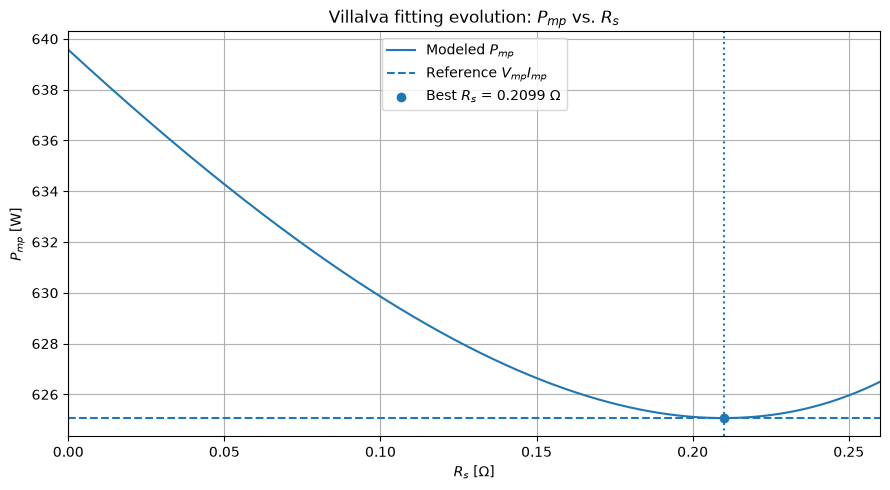

In [7]:
# Best Villalva iteration: closest Pmp to the reference value
best_idx = history["abs_power_error"].idxmin()
best = history.loc[best_idx]

print(f"Best R_s = {best['R_s']:.6f} ohm")
print(f"Modeled P_mp = {best['p_mp_model']:.6f} W")
print(f"Reference P_mp = {best['p_mp_ref']:.6f} W")
print(f"Absolute error = {best['abs_power_error']:.6e} W")

plt.figure(figsize=(9, 5))

plt.plot(
    history["R_s"],
    history["p_mp_model"],
    label="Modeled $P_{mp}$",
)

plt.axhline(
    module["P_mp_fit"],
    linestyle="--",
    label="Reference $V_{mp}I_{mp}$",
)

plt.scatter(
    [best["R_s"]],
    [best["p_mp_model"]],
    zorder=3,
    label=(
        f"Best $R_s$ = {best['R_s']:.4f} $\\Omega$"
    ),
)

plt.axvline(
    best["R_s"],
    linestyle=":",
)

plt.xlim(0, 0.26)

plt.xlabel("$R_s$ [$\\Omega$]")
plt.ylabel("$P_{mp}$ [W]")
plt.title("Villalva fitting evolution: $P_{mp}$ vs. $R_s$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Final fitted SDM parameters

In [8]:
parameter_table = pd.DataFrame(
    {
        "Value": [
            diode_factor,
            params["a_ref"],
            params["I_L_ref"],
            params["I_o_ref"],
            params["R_s"],
            params["R_sh_ref"],
        ],
        "Unit": [
            "-",
            "V",
            "A",
            "A",
            "ohm",
            "ohm",
        ],
    },
    index=[
        "diode_factor",
        "a_ref",
        "I_L_ref",
        "I_o_ref",
        "R_s",
        "R_sh_ref",
    ],
)

parameter_table

,Value,Unit
diode_factor,1.000000e+00,-
a_ref,2.004021e+00,V
I_L_ref,1.437770e+01,A
I_o_ref,1.325601e-11,A
R_s,2.099000e-01,ohm
R_sh_ref,1.703229e+02,ohm


## STC I–V curve and datasheet key-point validation

In [9]:
stc_sde = {
    "photocurrent": params["I_L_ref"],
    "saturation_current": params["I_o_ref"],
    "resistance_series": params["R_s"],
    "resistance_shunt": params["R_sh_ref"],
    "nNsVth": params["a_ref"],
}

stc = pvsystem.singlediode(
    method="lambertw",
    **stc_sde,
)

datasheet = pd.Series(
    {
        "i_sc": module["I_sc_ref"],
        "v_oc": module["V_oc_ref"],
        "i_mp": module["I_mp_ref"],
        "v_mp": module["V_mp_ref"],
        "p_mp": module["P_mp_fit"],
    }
)

model = pd.Series(
    {
        key: float(np.asarray(stc[key]))
        for key in ["i_sc", "v_oc", "i_mp", "v_mp", "p_mp"]
    }
)

validation = pd.DataFrame(
    {
        "Datasheet": datasheet,
        "Villalva": model,
    }
)

validation["Error"] = (
    validation["Villalva"]
    - validation["Datasheet"]
)

validation["Error [%]"] = (
    100
    * validation["Error"]
    / validation["Datasheet"]
)

validation

,Datasheet,Villalva,Error,Error [%]
i_sc,14.3600,14.360000,-4.633804e-11,-3.226883e-10
v_oc,55.4900,55.490000,-2.202682e-13,-3.969512e-13
i_mp,13.4800,13.480153,1.528975e-04,1.134254e-03
v_mp,46.3700,46.369474,-5.258821e-04,-1.134100e-03
p_mp,625.0676,625.067601,8.848201e-07,1.415559e-07


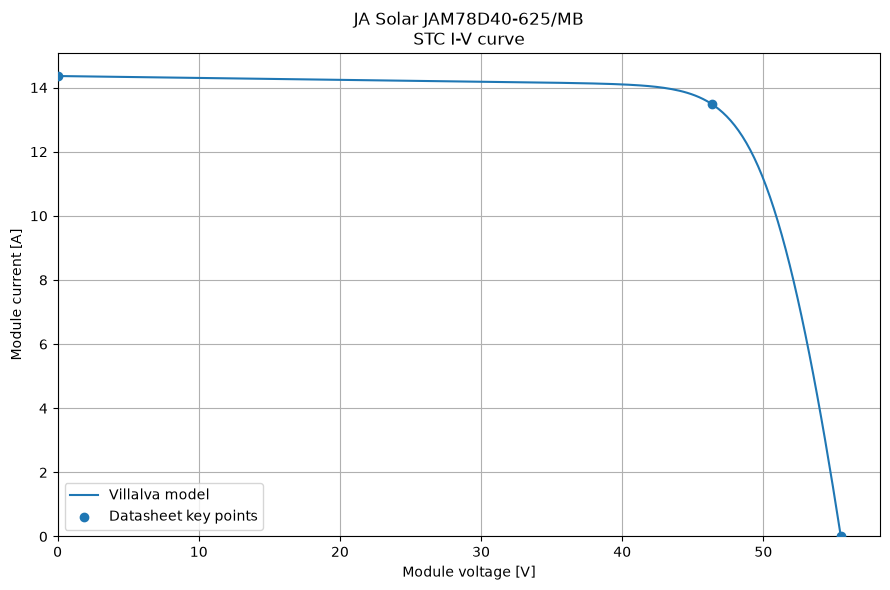

In [10]:
v_stc = np.linspace(
    0.0,
    float(stc["v_oc"]),
    200,
)

i_stc = pvsystem.i_from_v(
    voltage=v_stc,
    method="lambertw",
    **stc_sde,
)

plt.figure(figsize=(9, 6))

plt.plot(
    v_stc,
    i_stc,
    label="Villalva model",
)

plt.scatter(
    [0.0, module["V_mp_ref"], module["V_oc_ref"]],
    [module["I_sc_ref"], module["I_mp_ref"], 0.0],
    label="Datasheet key points",
    zorder=3,
)

plt.xlabel("Module voltage [V]")
plt.ylabel("Module current [A]")
plt.title(module["Name"] + "\nSTC I-V curve")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Additional validation: recover a known SDM parameter set

This test follows the validation proposed for the Villalva fitting algorithm:

1. assume a complete set of single-diode model parameters at STC;
2. use `pvlib.pvsystem.singlediode` to calculate the corresponding
   \(I_{sc}\), \(V_{oc}\), \(I_{mp}\), \(V_{mp}\), and \(P_{mp}\);
3. use those synthetic key points as inputs to `fit_villalva`;
4. compare the recovered SDM parameters with the original parameters.

The example uses the Canadian Solar CS5P-220M parameter set from the pvlib
single-diode gallery. Since the basic Villalva algorithm requires the
dimensionless diode ideality factor \(a\), it is calculated from the known
pvlib parameter

a_ref = a × N_s × (k × T_ref / q)

The purpose of this test is parameter recovery, so the inputs to Villalva are
the **synthetic key points calculated by `singlediode`**, not the rounded
datasheet values.

Synthetic STC key points


i_sc      5.099770
v_oc     59.400651
i_mp      4.689806
v_mp     46.902632
p_mp    219.964255
dtype: float64

Known Villalva diode ideality factor: 1.069253300


,Starting value,Recovered value,Absolute error,Relative error [%]
I_L_ref,5.114000e+00,5.114000e+00,-6.269092e-09,-1.225869e-07
I_o_ref,8.196000e-10,8.196000e-10,1.605503e-19,1.958886e-08
R_s,1.065000e+00,1.065000e+00,0.000000e+00,0.000000e+00
R_sh_ref,3.816800e+02,3.816800e+02,1.775631e-05,4.652146e-06
a_ref,2.637300e+00,2.637300e+00,-4.440892e-16,-1.683878e-14


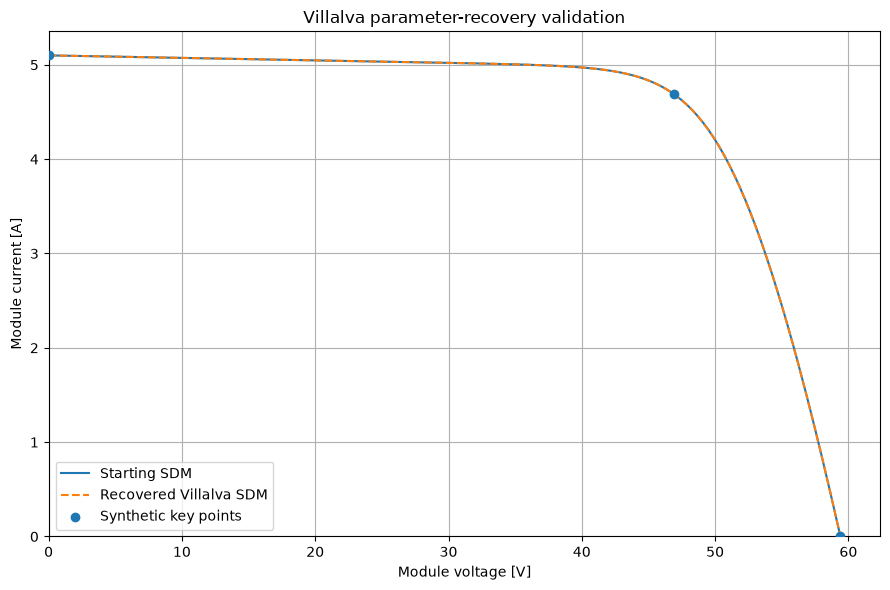

In [11]:
# ---------------------------------------------------------------------
# 1. Assume a known SDM parameter set at STC
# ---------------------------------------------------------------------
known = {
    "Name": "Canadian Solar CS5P-220M",
    "N_s": 96,
    "alpha_sc": 0.004539,       # A/K
    "beta_voc": -0.22216,       # V/K
    "a_ref": 2.6373,            # n * Ns * Vth [V]
    "I_L_ref": 5.114,           # A
    "I_o_ref": 8.196e-10,       # A
    "R_s": 1.065,               # ohm
    "R_sh_ref": 381.68,         # ohm
    "temp_ref": 25.0,           # degC
    "irrad_ref": 1000.0,        # W/m2
}

# Convert pvlib a_ref to Villalva's dimensionless diode ideality factor.
T_ref_K = known["temp_ref"] + 273.15

diode_factor_known = (
    known["a_ref"]
    / (
        known["N_s"]
        * constants.k
        * T_ref_K
        / constants.e
    )
)


# ---------------------------------------------------------------------
# 2. Generate synthetic Isc, Voc, Imp, Vmp and Pmp with pvlib
# ---------------------------------------------------------------------
synthetic = pvsystem.singlediode(
    photocurrent=known["I_L_ref"],
    saturation_current=known["I_o_ref"],
    resistance_series=known["R_s"],
    resistance_shunt=known["R_sh_ref"],
    nNsVth=known["a_ref"],
    method="lambertw",
)

synthetic_points = {
    key: float(np.asarray(synthetic[key]))
    for key in ["i_sc", "v_oc", "i_mp", "v_mp", "p_mp"]
}

print("Synthetic STC key points")
display(pd.Series(synthetic_points))


# ---------------------------------------------------------------------
# 3. Apply the basic Villalva algorithm to the synthetic key points
# ---------------------------------------------------------------------
recovered, recovery_history = fit_villalva(
    v_mp=synthetic_points["v_mp"],
    i_mp=synthetic_points["i_mp"],
    v_oc=synthetic_points["v_oc"],
    i_sc=synthetic_points["i_sc"],
    alpha_sc=known["alpha_sc"],
    beta_voc=known["beta_voc"],
    cells_in_series=known["N_s"],
    diode_factor=diode_factor_known,
    temp_ref=known["temp_ref"],
    irrad_ref=known["irrad_ref"],
    rs_step=1e-4,
    rs_max=1.5,
)


# ---------------------------------------------------------------------
# 4. Compare original and recovered SDM parameters
# ---------------------------------------------------------------------
parameter_names = [
    "I_L_ref",
    "I_o_ref",
    "R_s",
    "R_sh_ref",
    "a_ref",
]

recovery_table = pd.DataFrame(
    {
        "Starting value": [
            known[name] for name in parameter_names
        ],
        "Recovered value": [
            recovered[name] for name in parameter_names
        ],
    },
    index=parameter_names,
)

recovery_table["Absolute error"] = (
    recovery_table["Recovered value"]
    - recovery_table["Starting value"]
)

recovery_table["Relative error [%]"] = (
    100
    * recovery_table["Absolute error"]
    / recovery_table["Starting value"]
)

print(
    f"Known Villalva diode ideality factor: "
    f"{diode_factor_known:.9f}"
)
display(recovery_table)


# ---------------------------------------------------------------------
# 5. Compare the complete original and recovered I-V curves
# ---------------------------------------------------------------------
v_validation = np.linspace(
    0.0,
    synthetic_points["v_oc"],
    300,
)

i_original = pvsystem.i_from_v(
    voltage=v_validation,
    photocurrent=known["I_L_ref"],
    saturation_current=known["I_o_ref"],
    resistance_series=known["R_s"],
    resistance_shunt=known["R_sh_ref"],
    nNsVth=known["a_ref"],
    method="lambertw",
)

i_recovered = pvsystem.i_from_v(
    voltage=v_validation,
    photocurrent=recovered["I_L_ref"],
    saturation_current=recovered["I_o_ref"],
    resistance_series=recovered["R_s"],
    resistance_shunt=recovered["R_sh_ref"],
    nNsVth=recovered["a_ref"],
    method="lambertw",
)

plt.figure(figsize=(9, 6))

plt.plot(
    v_validation,
    i_original,
    label="Starting SDM",
)

plt.plot(
    v_validation,
    i_recovered,
    linestyle="--",
    label="Recovered Villalva SDM",
)

plt.scatter(
    [
        0.0,
        synthetic_points["v_mp"],
        synthetic_points["v_oc"],
    ],
    [
        synthetic_points["i_sc"],
        synthetic_points["i_mp"],
        0.0,
    ],
    label="Synthetic key points",
    zorder=3,
)

plt.xlabel("Module voltage [V]")
plt.ylabel("Module current [A]")
plt.title("Villalva parameter-recovery validation")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# I–V curves under operating conditions

The workflow is intentionally parallel to pvlib's De Soto gallery example:

1. use `calcparams_villalva` to calculate the five SDM parameters for each
   irradiance and cell temperature;
2. use `pvsystem.singlediode` and `pvsystem.i_from_v` to solve the I–V curves.

The same operating-condition cases used in the De Soto example are used here.

In [12]:
cases = [
    (1000, 55),
    (800, 55),
    (600, 55),
    (400, 25),
    (400, 40),
    (400, 55),
]

conditions = pd.DataFrame(
    cases,
    columns=["Geff", "Tcell"],
)

IL, I0, Rs, Rsh, nNsVth = calcparams_villalva(
    effective_irradiance=conditions["Geff"],
    temp_cell=conditions["Tcell"],
    alpha_sc=params["alpha_sc"],
    beta_voc=params["beta_voc"],
    a_ref=params["a_ref"],
    I_L_ref=params["I_L_ref"],
    R_sh_ref=params["R_sh_ref"],
    R_s=params["R_s"],
    i_sc_ref=params["i_sc_ref"],
    v_oc_ref=params["v_oc_ref"],
    irrad_ref=params["irrad_ref"],
    temp_ref=params["temp_ref"],
)

SDE_params = {
    "photocurrent": IL,
    "saturation_current": I0,
    "resistance_series": Rs,
    "resistance_shunt": Rsh,
    "nNsVth": nNsVth,
}

curve_info = pvsystem.singlediode(
    method="lambertw",
    **SDE_params,
)

v = pd.DataFrame(
    np.linspace(
        0.0,
        curve_info["v_oc"],
        100,
    )
)

i = pd.DataFrame(
    pvsystem.i_from_v(
        voltage=v,
        method="lambertw",
        **SDE_params,
    )
)

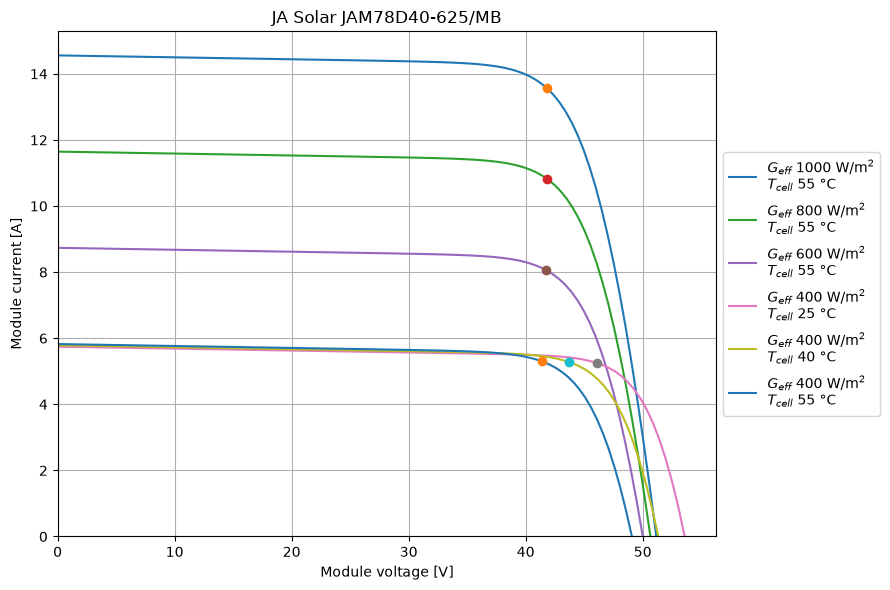

In [13]:
plt.figure(figsize=(9, 6))

for idx, case in conditions.iterrows():

    label = (
        "$G_{eff}$ "
        + f"{case['Geff']:.0f} W/m$^2$\n"
        "$T_{cell}$ "
        + f"{case['Tcell']:.0f} °C"
    )

    plt.plot(
        v[idx],
        i[idx],
        label=label,
    )

    plt.plot(
        [curve_info["v_mp"][idx]],
        [curve_info["i_mp"][idx]],
        linestyle="",
        marker="o",
    )

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel("Module voltage [V]")
plt.ylabel("Module current [A]")
plt.title(module["Name"])

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
operating_results = pd.DataFrame(
    {
        "Geff [W/m2]": conditions["Geff"],
        "Tcell [degC]": conditions["Tcell"],
        "i_sc [A]": curve_info["i_sc"],
        "v_oc [V]": curve_info["v_oc"],
        "i_mp [A]": curve_info["i_mp"],
        "v_mp [V]": curve_info["v_mp"],
        "p_mp [W]": curve_info["p_mp"],
    }
)

operating_results

,Geff [W/m2],Tcell [degC],i_sc [A],v_oc [V],i_mp [A],v_mp [V],p_mp [W]
0,1000,55,14.557924,51.161742,13.559335,41.829649,567.182223
1,800,55,11.646339,50.658502,10.812201,41.862314,452.623757
2,600,55,8.734754,50.005643,8.059633,41.748936,336.481106
3,400,25,5.744000,53.586921,5.251829,46.077520,241.991255
4,400,40,5.783585,51.330745,5.279107,43.707762,230.737973
5,400,55,5.823170,49.074853,5.303287,41.358770,219.337433


## Reference values for pvlib unit tests

The round-trip validation above can also provide fixed reference values for the
pvlib test suite.

The idea is to **archive the numerical results produced by this notebook** and
then use unit tests to verify that future implementations continue to reproduce
them. These are regression tests rather than an independent validation of the
model.

Two tests are useful:

1. `fit_villalva`: use fixed synthetic STC key points and verify that the
   extracted SDM parameters match the archived values.
2. `calcparams_villalva`: evaluate a few irradiance and temperature conditions,
   including `NaN`, and compare the five returned SDM parameters against
   archived results.

Keeping the reference values explicitly in the notebook provides the provenance
for the values later copied into the pvlib test files.


In [15]:
# Archived inputs and expected outputs for a fit_villalva regression test

FIT_VILLALVA_INPUT = {
    "v_mp": 46.90263243704522,
    "i_mp": 4.6898061801386035,
    "v_oc": 59.40065126750112,
    "i_sc": 5.099770128570936,
    "alpha_sc": 0.004539,
    "beta_voc": -0.22216,
    "cells_in_series": 96,
    "diode_factor": 1.0692532995822863,
    "temp_ref": 25.0,
    "irrad_ref": 1000.0,
    "rs_step": 1e-4,
    "rs_max": 1.5,
}

FIT_VILLALVA_EXPECTED = {
    "I_L_ref": 5.113999993730909,
    "I_o_ref": 8.196000001605002e-10,
    "R_s": 1.065,
    "R_sh_ref": 381.6800177562556,
    "a_ref": 2.6373,
}

fit_result, _ = fit_villalva(**FIT_VILLALVA_INPUT)

fit_test_table = pd.DataFrame({
    "Archived": FIT_VILLALVA_EXPECTED,
    "Recomputed": {
        key: fit_result[key]
        for key in FIT_VILLALVA_EXPECTED
    },
})

fit_test_table["Difference"] = (
    fit_test_table["Recomputed"]
    - fit_test_table["Archived"]
)

fit_test_table


,Archived,Recomputed,Difference
I_L_ref,5.114000e+00,5.114000e+00,0.000000e+00
I_o_ref,8.196000e-10,8.196000e-10,-2.998530e-24
R_s,1.065000e+00,1.065000e+00,0.000000e+00
R_sh_ref,3.816800e+02,3.816800e+02,0.000000e+00
a_ref,2.637300e+00,2.637300e+00,-4.440892e-16


### `calcparams_villalva` reference cases

The following cases test normal operating conditions as well as `NaN`
propagation.

For the case with `effective_irradiance = NaN` and a valid temperature,
photocurrent is `NaN`, while saturation current remains finite because
Villalva's \(I_0\) temperature equation does not depend on irradiance.

When cell temperature is `NaN`, all temperature-dependent quantities become
`NaN`.


In [16]:
# Archived inputs and expected outputs for calcparams_villalva

effective_irradiance_test = np.array([
    1000.0,
    800.0,
    400.0,
    np.nan,
    600.0,
])

temp_cell_test = np.array([
    25.0,
    45.0,
    55.0,
    25.0,
    np.nan,
])

CALCPARAMS_EXPECTED = (
    np.array([
        5.113999993730909,
        4.163823994984726,
        2.100067997492364,
        np.nan,
        np.nan,
    ]),
    np.array([
        8.196000001605002e-10,
        1.671475175084766e-08,
        6.581579176008610e-08,
        8.196000001605002e-10,
        np.nan,
    ]),
    1.065,
    381.6800177562556,
    np.array([
        2.6373,
        2.814210950863659,
        2.902666426295489,
        2.6373,
        np.nan,
    ]),
)

calcparams_result = calcparams_villalva(
    effective_irradiance=effective_irradiance_test,
    temp_cell=temp_cell_test,
    alpha_sc=0.004539,
    beta_voc=-0.22216,
    a_ref=2.6373,
    I_L_ref=5.113999993730909,
    R_sh_ref=381.6800177562556,
    R_s=1.065,
    i_sc_ref=5.099770128570936,
    v_oc_ref=59.40065126750112,
    irrad_ref=1000.0,
    temp_ref=25.0,
)

calcparams_test_table = pd.DataFrame({
    "Geff [W/m2]": effective_irradiance_test,
    "Tcell [degC]": temp_cell_test,
    "I_L expected [A]": CALCPARAMS_EXPECTED[0],
    "I_L calculated [A]": calcparams_result[0],
    "I_o expected [A]": CALCPARAMS_EXPECTED[1],
    "I_o calculated [A]": calcparams_result[1],
    "nNsVth expected [V]": CALCPARAMS_EXPECTED[4],
    "nNsVth calculated [V]": calcparams_result[4],
})

calcparams_test_table


,Geff [W/m2],Tcell [degC],I_L expected [A],I_L calculated [A],I_o expected [A],I_o calculated [A],nNsVth expected [V],nNsVth calculated [V]
0,1000.0,25.0,5.114000,5.114000,8.196000e-10,8.196000e-10,2.637300,2.637300
1,800.0,45.0,4.163824,4.163824,1.671475e-08,1.671475e-08,2.814211,2.814211
2,400.0,55.0,2.100068,2.100068,6.581579e-08,6.581579e-08,2.902666,2.902666
3,NaN,25.0,NaN,NaN,8.196000e-10,8.196000e-10,2.637300,2.637300
4,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Pytest-style checks

The actual pvlib contribution should place these checks in the test suite rather
than rely on the notebook. `equal_nan=True` is important for the operating
condition test.


In [17]:
# These assertions mirror the tests that can be added to pvlib.

np.testing.assert_allclose(
    [fit_result[key] for key in FIT_VILLALVA_EXPECTED],
    [FIT_VILLALVA_EXPECTED[key] for key in FIT_VILLALVA_EXPECTED],
    rtol=1e-7,
    atol=1e-12,
)

for calculated, expected in zip(
    calcparams_result,
    CALCPARAMS_EXPECTED,
):
    np.testing.assert_allclose(
        calculated,
        expected,
        rtol=1e-10,
        atol=1e-12,
        equal_nan=True,
    )

print("Archived Villalva reference tests passed.")


Archived Villalva reference tests passed.


## Notes for a pvlib-python API reference addition

The two proposed public functions represented by this notebook are:

```python
pvlib.ivtools.sdm.fit_villalva(...)
pvlib.pvsystem.calcparams_villalva(...)
```

`fit_villalva` is analogous in role to `pvlib.ivtools.sdm.fit_desoto`: it
extracts reference-condition SDM parameters from module datasheet values.

`calcparams_villalva` is analogous in role to
`pvlib.pvsystem.calcparams_desoto`: it converts the reference parameters to
the five SDM parameters at an arbitrary irradiance and cell temperature.

The actual I–V solution continues to use the existing pvlib functions
`pvsystem.singlediode` and `pvsystem.i_from_v`.